## Introduction
The goal of this project is to perform RFM (Recency, Frequency, Monetary) analysis on transactional retail data to identify high-value customers and generate actionable insights for marketing and customer retention strategies.

### Loading Data

In [ ]:
import sqlite3
import pandas as pd

df = pd.read_csv('retail_cleaned.csv')

conn = sqlite3.connect('retail.db')

df.to_sql('transactions', conn, if_exists='replace', index=False)

Loading the cleaned dataset into a SQLite database to perform SQL-based aggregation of transaction-level data into customer-level RFM metrics.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [26]:
query = """
SELECT 
    CustomerID,
    julianday('2011-12-10') - julianday(MAX(InvoiceDate)) AS recency,
    COUNT(DISTINCT InvoiceNo) AS frequency,
    SUM(TotalPrice) AS monetary
FROM transactions
GROUP BY CustomerID
"""
rfm_df = pd.read_sql(query, conn)
conn.close()

Here I created a table containing columns for CustomerID, Recency, Frequency, and Monetary. 
Recency was calculated using the dataset's end date as the reference point rather than today's date to ensure that recency scores reflect purchasing behavior within the data collection period rather than being distorted by time elapsed since its publication. 

## Exploratory Analysis

In [29]:
print(rfm_df.describe())

         CustomerID      recency    frequency       monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.514594     4.272015    2054.266460
std     1721.808492   100.013298     7.697998    8989.230441
min    12346.000000     0.465278     1.000000       3.750000
25%    13813.250000    17.537674     1.000000     307.415000
50%    15299.500000    50.555208     2.000000     674.485000
75%    16778.750000   142.195833     5.000000    1661.740000
max    18287.000000   373.588194   209.000000  280206.020000


The data shows that the std of the monetary category is £8,989 while the mean is only £2,054, indicating that the distribution is extremely right-skewed. Additionally, the frequency statistics report the median frequency of purchases at 2, whereas the max number of transactions for a customer is 209. The skew observed across these metrics indicates that a small subset of customers drives disproportionate spending and activity, requiring segmentation rather than a uniform treatment of the customer base. This is consistent with the dataset's documentation noting the presence of wholesale buyers.

## RFM Scoring

In [30]:
rfm_df['R_score'] = pd.qcut(rfm_df['recency'], 5, labels=[5,4,3,2,1])
rfm_df['F_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm_df['M_score'] = pd.qcut(rfm_df['monetary'], 5, labels=[1,2,3,4,5])


I created quintiles for each RFM category, with 5 being a great score, and 1 being weak. The labelling is reversed for recency because 5's go to customers with the lowest numbers, as that means they have purchased more recently. For both the frequency and monetary categories, the value assignment is reversed, as we want the highest values to receive 5's. 

In [37]:
rfm_df['RFM_score'] = (
    rfm_df['R_score'].astype(int) +
    rfm_df['F_score'].astype(int) +
    rfm_df['M_score'].astype(int)
)

Adding up the scores of each RFM category to get the final RFM score of each customer. Scores will range from 3, being the lowest value customers, to 15, at highest value. 

### Customer Segmentation

In [38]:
def segment_customer(score):
    if score >= 12:
        return 'High Value'
    elif score >= 8:
        return 'Mid Value'
    else:
        return 'Low Value'

rfm_df['segment'] = rfm_df['RFM_score'].apply(segment_customer)

Customers are therefore segmented into Low, Mid, and High Value groups based on their composite RFM score.

## Segmentation Analysis

In [151]:
segment_order = ['Low Value', 'Mid Value', 'High Value']
summary = pd.DataFrame({
    'Customer Count': rfm_df.groupby('segment')['CustomerID'].count(),
    'Cust. Proportion': rfm_df.groupby('segment')['CustomerID'].count() / rfm_df['CustomerID'].nunique(),
    'Total Revenue': rfm_df.groupby('segment')['monetary'].sum(),
    'Revenue Proportion': rfm_df.groupby('segment')['monetary'].sum() / rfm_df['monetary'].sum(),
}).reindex(segment_order)
summary

,Customer Count,Cust. Proportion,Total Revenue,Revenue Proportion
segment,,,,
Low Value,1693,0.390272,637225.851,0.071507
Mid Value,1399,0.322499,1461232.103,0.163973
High Value,1246,0.287229,6812949.950,0.764520


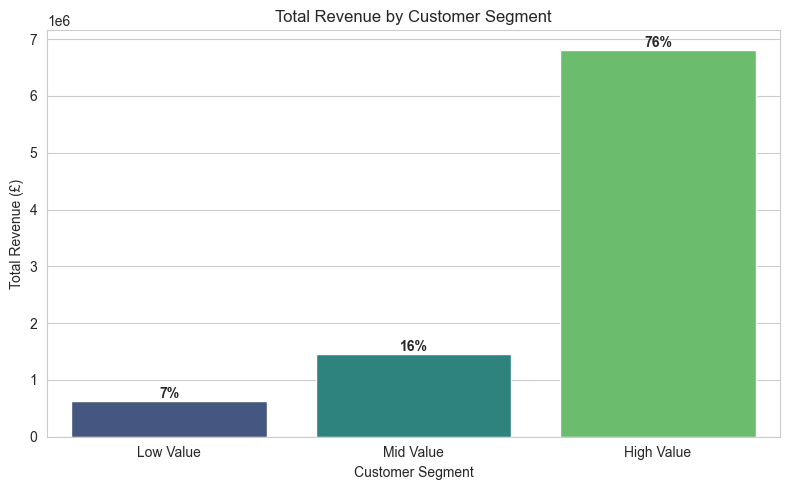

In [155]:
segment_revenue = rfm_df.groupby('segment')['monetary'].sum().reindex(segment_order)

plt.figure(figsize=(8, 5))
sns.barplot(x=segment_revenue.index, y=segment_revenue.values, 
            hue=segment_revenue.index, palette='viridis', legend=False)
for i, (val, pct) in enumerate(zip(segment_revenue.values, summary['Revenue Proportion'])):
    plt.text(i, val + 50000, f'{pct:.0%}', ha='center', fontweight='bold')
plt.title('Total Revenue by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig('../results/revenue_by_segment.png')
plt.show()

High-value customers make up 29% of the customer base yet contribute 76% of total 
revenue, while low-value customers represent 39% of customers but account for just 7%. 
This concentration is partly a product of the segmentation method, which relies on fixed score 
thresholds (≥12, ≥8) rather than equal splits. This naturally produces fewer high-value 
customers, which reflects real-world purchasing behavior where a small group of loyal, 
high-spending buyers drives the majority of revenue.

In [156]:
rfm_df.groupby('segment')[['recency','frequency','monetary']].mean().reindex(segment_order)

,recency,frequency,monetary
segment,,,
Low Value,170.318072,1.239220,376.388571
Mid Value,63.864584,2.850608,1044.483276
High Value,18.967304,9.988764,5467.857103


Taking the average of each customer segment's RFM score shows that mid-value customers purchased relatively recently, averaging at 64 days since their last purchase and have moderate transaction frequency, with an average of 2.85 purchases. These findings suggest that mid-value customers are engaged but underutilized. On the other hand, low-value customers average 170 days since last purchase and average only 1.2 orders, indicating that many of them are likely one-time buyers who never returned.

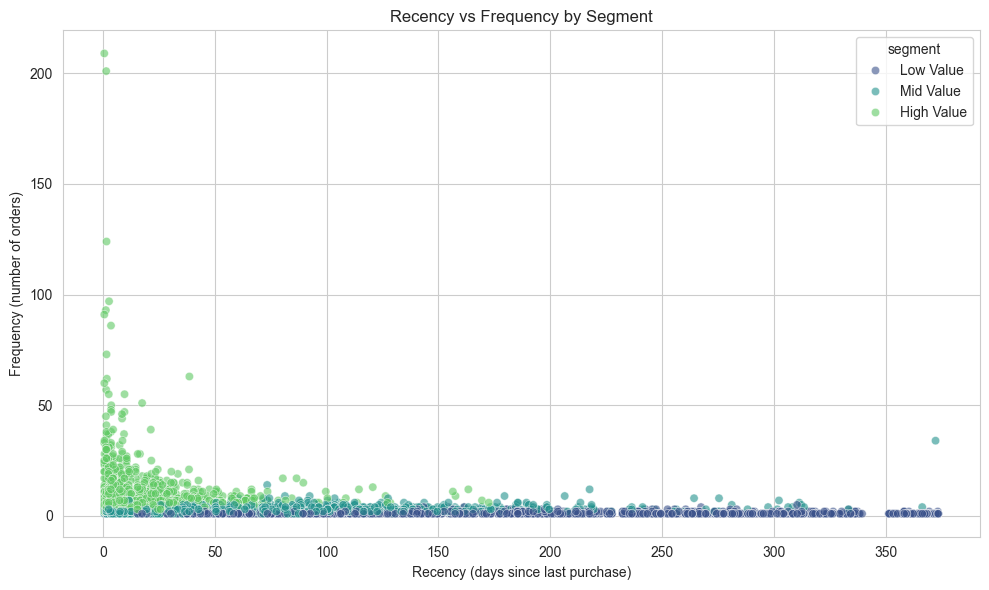

In [157]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm_df, x='recency', y='frequency', 
                hue='segment', hue_order=segment_order,
                palette='viridis', alpha=0.6)
plt.title('Recency vs Frequency by Segment')
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Frequency (number of orders)')
plt.tight_layout()
plt.savefig('../results/recency_vs_frequency.png')
plt.show()

The scatter plot highlights the behavioral separation across customer segments. High-value customers are clustered in the bottom-left, and scattered up the y-axis indicating recent and frequent purchasing, while low-value customers are dispersed toward the right with low frequency.

## Recommendations
- **High-Value Customers (29% of customers, 77% of revenue)**  
  These customers are the business's main source of revenue. As a result, the company should prioritize customer retention over acquisition.

  *Recommended actions:* Early access perks, exclusive product previews, and dedicated account management for the highest spenders.

- **Mid-Value Customers (32% of customers, 16% of revenue)**  
  With an average recency of 64 days and moderate frequency, this group is still engaged and represents the highest conversion opportunity.

  *Recommended actions:* Personalized re-engagement campaigns based on past purchase categories, and loyalty incentives with clear progression toward high-value status.

- **Low-Value Customers (39% of customers, 7% of revenue)**  
  Averaging 170 days since last purchase with a median of 1-2 orders, many of these customers are likely one-time buyers. ROI for this group is likely low.

  *Recommended actions:* Low-cost automated win-back emails, and filtering out customers with recency over 300 days from active campaigns entirely.